# hyperproc, end to end on Tanager

A tutorial and a test at once. It walks the whole package on one Tanager granule, from
opening a file to writing a corrected, quality-flagged, analysis-ready product.

Every function is introduced with a table of **its parameters and what each one does**,
so you can change the behaviour rather than copy the call. Where a default was chosen for
a reason, the reason is given.

**This granule:** 665 x 782 pixels at 30 m, EPSG:32642, 426 bands, 376 to 2499 nm - the finest spectral sampling of the five.

Tanager samples 426 bands over the same range EnMAP covers with 224, so it is the best of the five for anything that depends on narrow features - and the scene is small, which makes it the quickest whole-scene run in this set.

## The corrections, and the order they go in

| Stage | What it removes | Applies to |
|---|---|---|
| **Atmospheric** | the atmosphere between the surface and the sensor | any L1B radiance |
| **BRDF** | brightness that comes from the viewing and illumination angles | any reflectance |
| *Topographic* | *brightness from the slope facing the sun* | *airborne only* |

**Atmospheric correction comes first.** It turns radiance into surface reflectance, and
the geometric corrections are defined on reflectance, so nothing else can run before it.
BRDF normalisation then removes the effect of the viewing and illumination angles.

**Topographic correction is not part of the satellite route.** In this package it is
restricted to airborne flightlines, where metre pixels make the terrain signal strong and
a flightline group gives the angular spread needed to separate terrain from view angle.
For Tanager, as for every other satellite the package reads, the chain is atmospheric then
BRDF. The airborne notebooks cover the topographic stage.

## The three ways in, and what each produces

| You have | You run | You get |
|---|---|---|
| L1B radiance | step 3.1 | `*_ac.tif` |
| L1B radiance | step 3.2 | `*_ac_brdf.tif` in one call |
| **a saved `*_ac.tif`** | **step 3.3** | `*_ac_brdf.tif` without redoing the retrieval |
| L2A reflectance | step 4 | `*_brdf.tif` |

Every one of those can be written as GeoTIFF or as ENVI; step 0 has the switch.

## What you need

* the Tanager granule in `tests/data/Tanager`: the L1B file (top-of-atmosphere radiance, already orthorectified) and the
  L2A file (Planet's own surface reflectance, on the same grid), plus the sibling metadata the reader finds by itself;
* for the atmospheric correction, ISOFIT. `pip install 'hyperproc[atmos]'` then
  `hyperproc-atmos-setup` once, which fetches the radiative-transfer engines and the
  surface libraries (several GB);
* for the BRDF correction, Earth Engine. `pip install 'hyperproc[brdf]'` and
  `earthengine authenticate` once.

Everything is computed from the granule and written into `tests/output/TANAGER_window`.
This notebook uses a 200 x 200 window, so the retrieval takes minutes rather than hours.

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "hyperproc").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline
import rasterio
import hyperproc as hp
from hyperproc import correct          # binds hp.correct; step 4 needs it even if step 3 is skipped

warnings.filterwarnings("ignore", category=RuntimeWarning)
print("hyperproc", hp.__version__, "from", REPO)

hyperproc 0.1.0.dev0 from /data/fujiang/Hyperspectral_data_processing


## Step 0 — the control panel

Everything worth changing is in one cell, so you can set it once and run the notebook
straight through.

| Parameter | What it controls |
|---|---|
| `WINDOW` | `None` processes the whole granule; a `{"y": (a, b), "x": (c, d)}` dict processes a subset. It indexes the **L1B grid**, and step 1 works out which part of the L2A that is |
| `WORKERS` | cores given to the ISOFIT retrieval |
| `EXPORT_FORMAT` | `"GTiff"` or `"ENVI"`. Every product below follows it |
| `SZA_REF`, `VZA_REF` | the geometry the BRDF step normalises to. 45 degrees and nadir is the usual convention |
| `SPECTRAL_MAP` | how MODIS's seven correction factors reach Tanager's bands |
| `DIAG_NM` | the wavelength used for the maps and comparisons |
| `RUN_AC`, `RUN_BRDF`, `RUN_POST` | switch off a whole section if you only want part of the notebook |
| `OUT` | follows `WINDOW`: `tests/output/TANAGER` for a whole scene, `tests/output/TANAGER_window` for a subset, so the two runs never share an ISOFIT working directory |

`HYPERPROC_CACHE_DIR` is redirected into the output folder so the compiled surface priors
and any downloaded elevation tiles land with the products instead of in your home
directory.

In [2]:
# ---- what to run -----------------------------------------------------------------
RUN_AC        = True
RUN_BRDF      = True
RUN_POST      = True
EXPORT_FORMAT = "GTiff"    # or "ENVI"

# ---- processing parameters -------------------------------------------------------
WINDOW       = {"y": (230, 430), "x": (290, 490)}   # a 200 x 200 subset, for a quick pass
WORKERS      = 20
SZA_REF      = 45.0        # or "observed" to keep each pixel's own sun angle
VZA_REF      = 0.0
SPECTRAL_MAP = "nearest"   # or "interp"
DIAG_NM      = 865.0

# ---- where things go -------------------------------------------------------------
# the folder follows WINDOW, so a subset run and a whole-scene run never share an
# ISOFIT working directory and cannot reuse each other's retrieval by accident
DATA = REPO / "tests" / "data"
OUT  = REPO / "tests" / "output" / ("TANAGER" if WINDOW is None else "TANAGER_window")
OUT.mkdir(parents=True, exist_ok=True)

L1_GLOB   = "Tanager/*_ortho_radiance_hdf5.h5"
L2_GLOB   = "Tanager/*_ortho_sr_hdf5.h5"
LIKE_GLOB = None

WORK_DIR  = OUT / "02_ac" / "isofit"        # ISOFIT's working directory
MODIS_DIR = OUT / "03_ac_brdf" / "mcd43"    # MODIS BRDF parameters land here
os.environ["HYPERPROC_CACHE_DIR"] = str(OUT / "cache")   # surface priors, elevation tiles

EXT = hp.FORMATS[EXPORT_FORMAT]
print(f"output  {OUT}")
print(f"format  {EXPORT_FORMAT} ({EXT})")
print(f"window  {WINDOW or 'whole scene'}")

output  /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window
format  GTiff (.tif)
window  {'y': (230, 430), 'x': (290, 490)}


### Two helpers, because a row number is not a place

`WINDOW` above is worth one warning, and it applies to every raster comparison you will
ever write. When `WINDOW` is set, a product covers a **small patch somewhere inside the
scene**, not the scene's top-left corner. Comparing `product[:h, :w]` with `scene[:h, :w]`
then puts two completely different pieces of ground side by side.

Line up by **coordinate**, never by array index. These helpers do that, and every
comparison below goes through them.

| Helper | What it does |
|---|---|
| `raster_grid(path)` | the pixel-centre coordinates of a raster on disk, read from its affine transform |
| `same_ground(ds, x, y)` | the part of a dataset covering those coordinates. `method="nearest"` with a one-pixel `tolerance` means a grid that does not really overlap raises, instead of quietly handing back the wrong pixels |
| `for_export(ds)` | a dataset ready to write. A raster file needs a map projection, so a swath is passed through `hp.georeference` first and anything already projected is returned untouched |

They work unchanged when `WINDOW` is `None`: the product then covers the whole scene and
the selection is the identity.

In [3]:
def raster_grid(path):
    '''Pixel-centre coordinates (x, y) of a raster on disk.'''
    with rasterio.open(path) as src:
        tr = src.transform
        return (tr.c + (np.arange(src.width) + 0.5) * tr.a,
                tr.f + (np.arange(src.height) + 0.5) * tr.e)


def same_ground(ds, x, y):
    '''The part of `ds` covering those coordinates, to within one pixel.'''
    tol = abs(float(ds.x[1] - ds.x[0]))
    return ds.sel(x=x, y=y, method="nearest", tolerance=tol)


def for_export(ds):
    '''A dataset ready to write: a swath is projected first, a grid passes through.

    GeoTIFF and ENVI both need a map projection. A swath has per-pixel latitude
    and longitude instead, so it is resampled onto a regular grid. Integer flag
    layers survive this unchanged.
    '''
    return ds if ds.attrs.get("crs") else hp.georeference(ds)

## Step 1 — reading

### `hp.open(path, sensor=None, level=None, **kwargs)`

The only entry point you need. It works out the sensor and level from the filename, finds
the sibling files, and returns an `xarray.Dataset` with the same shape of metadata
whatever the instrument: `reflectance` or `radiance` on `(y, x, wavelength)`, the
wavelength and FWHM as coordinates, and the geometry and masks as 2-D layers.

| Parameter | Default | What it does |
|---|---|---|
| `path` | — | the main file. The siblings this reader needs are found automatically |
| `sensor`, `level` | guessed | override when the filename has been changed and cannot be recognised |

Tanager's reader (`open_tanager`) takes these, passed through as keyword arguments:

| Parameter | Default | What it does |
|---|---|---|
| `wl_range` | `None` | `(400, 1000)` loads only part of the spectrum |
| `good_bands_only` | `False` | drop the bands Planet flags unusable rather than keeping them as NaN |
| `masks` | `True` | attach Planet's cloud and related masks |
| `geometry` | `True` | attach the sun and view angles. **Leave this on**: the BRDF step needs them |
| `extras` | `True` | attach the extra retrieved layers Planet ships |
| `uncertainty` | `False` | also read the uncertainty cube, which doubles the read |

Nothing is read from disk here. The cube is lazy, so opening a large granule is instant
and only the parts you touch are loaded.

### Four helpers for looking before you leap

| Call | What it gives you |
|---|---|
| `hp.sniff(path)` | the sensor, level, granule name and acquisition time **without opening the cube** |
| `hp.summary()` | one line per reader: the sensors the installed version can read |
| `hp.list_readers()` | the full table, including which levels each reader handles |
| `hp.describe(ds, var=None)` | the band table, value ranges and layers of an opened dataset |
| `hp.main_var(ds)` | the name of the cube, `"reflectance"` or `"radiance"`, so your code need not guess |

In [4]:
print(hp.summary())          # one line per reader
hp.list_readers()            # the full table: which sensors and levels, and what each expects

Implemented: AVIRIS L1B, AVIRIS L2A, AVIRIS-CLASSIC L1B, AVIRIS-CLASSIC L2A, AVIRIS-NG L1B, AVIRIS-NG L2A, AVIRIS3 L1B, AVIRIS3 L2A, AVIRIS5 L1B, AVIRIS5 L2A, DESIS L1B, DESIS L1C, DESIS L2A, EMIT L1B, EMIT L2A, ENMAP L1B, ENMAP L1C, ENMAP L2A, NEON L1, PACE L1B, PACE L2, PRISMA L1, PRISMA L2B, PRISMA L2C, PRISMA L2D, TANAGER L1B, TANAGER L2A. Planned: NEON.

  sensor   level  status         expects
  ----------------------------------------------------------------------------
  AVIRIS   L1B    ready          the radiance cube, its .hdr, or the folder holding it - *_RDN_ORT (AVIRIS-3), *_rdn_*_img (NG), *_sc01_ort_img (Classic)
  AVIRIS   L2A    ready          the reflectance cube, its .hdr, or the folder holding it - *_RFL_ORT (AVIRIS-3), *_RFL_ORT.nc (-5), *_rfl_*_img (NG), *_corr_*_img (Classic)
  AVIRIS-CLASSIC L1B    ready          AVIRIS-CLASSIC L1B cube, .hdr, or folder
  AVIRIS-CLASSIC L2A    ready          AVIRIS-CLASSIC L2A cube, .hdr, or folder
  AVIRIS-NG L1B    ready      

In [5]:
l1_path = sorted(DATA.glob(L1_GLOB))[0]
l2_path = sorted(DATA.glob(L2_GLOB))[0]

print("sniffed:", hp.sniff(l1_path), hp.sniff(l2_path))

l1 = hp.open(l1_path)      # top-of-atmosphere radiance, already orthorectified
l2 = hp.open(l2_path)      # Planet's own surface reflectance, on the same grid

for name, ds in (("L1B", l1), ("L2A", l2)):
    print(f"\n{name}: {dict(ds.sizes)}  var={hp.main_var(ds)}  units={ds.attrs.get('units')}")
    print(f"   crs={ds.attrs.get('crs') or 'none (swath - no map projection)'}")

sniffed: ('TANAGER', 'L1B') ('TANAGER', 'L2A')



L1B: {'wavelength': 426, 'y': 665, 'x': 782}  var=radiance  units=W/(m^2 sr um)
   crs=EPSG:32642

L2A: {'wavelength': 426, 'y': 665, 'x': 782}  var=reflectance  units=Unitless
   crs=EPSG:32642


In [6]:
# The L2A scenarios (steps 4 to 6) work on this. It is the whole granule when WINDOW is
# None, so a quick pass stays quick. L1B and L2A share one grid on Tanager, so the same
# row and column numbers pick out the same ground in both.
l2_sub = l2 if WINDOW is None else l2.isel(y=slice(*WINDOW["y"]), x=slice(*WINDOW["x"]))
print("the piece steps 4-6 use:", dict(l2_sub.sizes))

the piece steps 4-6 use: {'wavelength': 426, 'y': 200, 'x': 200}


In [7]:
hp.describe(l2)


  sensor     Tanager L2A
  granule    20250503_064345_16_4001_ortho_sr
  acquired   2025-05-03T06:43:45
  grid       665 x 782  (ortho)
  pixel      30.0 m
  extent     x 585450.0000 .. 608910.0000   y 4537740.0000 .. 4557690.0000
  bands      426   376.4 - 2499.0 nm   (fwhm 6.1 nm)
  flagged    58 bands flagged unusable (provider)
  valid px   ~100.0% of 520,030   (from a 4,356-px sample)
  reflectan  median 0.2011   p1 -0.0100   p99 0.4041
  masks      cloud=0.1%  cirrus=0.0%
  geometry   sza=26.3deg  saa=162.1deg  vza=6.4deg  vaa=98.6deg  raa=296.4deg



### The geometry, and why it matters later

Both corrections are functions of angle, so the reader attaches them per pixel: `sza` and
`saa` for the sun, `vza` and `vaa` for the sensor, and `raa` for the angle between them.

Read the **spread** below, not just the range. A narrow swath spans only a degree or two of view zenith, so the BRDF correction is mostly a change of level to the target geometry rather than the removal of an across-track gradient - and the validation at the end of step 4 has little to work with.

  sza       26.14 ..    26.37   spread    0.22
  saa      161.82 ..   162.44   spread    0.62
  vza        5.04 ..     7.76   spread    2.72
  vaa       87.67 ..   107.51   spread   19.83
  raa      285.24 ..   305.21   spread   19.97


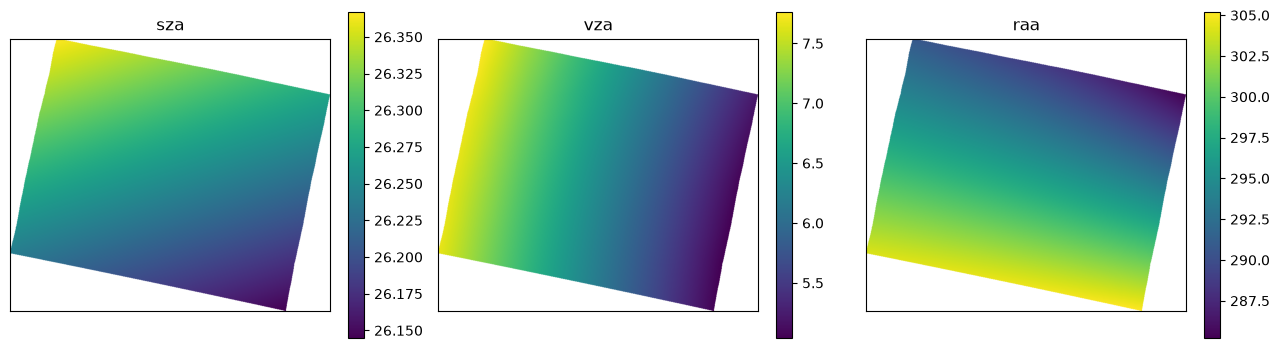

In [8]:
for v in ("sza", "saa", "vza", "vaa", "raa", "slope", "cos_i", "elev"):
    if v in l2:
        a = np.asarray(l2[v].values, dtype="float64")
        print(f"  {v:6s} {np.nanmin(a):8.2f} .. {np.nanmax(a):8.2f}   spread {np.nanmax(a)-np.nanmin(a):7.2f}")

layers = [v for v in ("sza", "vza", "raa", "cos_i", "elev") if v in l2][:4]
fig, ax = plt.subplots(1, len(layers), figsize=(4.3 * len(layers), 3.6))
for a, v in zip(np.atleast_1d(ax), layers):
    im = a.imshow(l2[v].values, cmap="viridis"); a.set_title(v); a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## Step 2 — writing, in either format

### `hp.to_geotiff(ds, path, var=None, compress="deflate", overviews=None, overview_resampling="average")`

| Parameter | Default | What it does |
|---|---|---|
| `path` | — | a `.tif`, or a **directory**, in which case the file is named after the granule |
| `var` | the cube | which variable to write |
| `compress` | `"deflate"` | lossless, roughly halves the file. `None` writes uncompressed |
| `overviews` | `None` | `True` builds internal pyramids so a GIS can draw the scene without reading it at full resolution; a list like `[2, 4, 8]` sets the factors |
| `overview_resampling` | `"average"` | right for reflectance. Use `"nearest"` or `"mode"` for a classification or a flag layer, where averaging would invent values |

### `hp.to_envi(ds, path, var=None, interleave="bil")`

| Parameter | Default | What it does |
|---|---|---|
| `path` | — | an `.img`, or a directory. The header is written beside it as `<stem>.hdr` |
| `var` | the cube | which variable to write |
| `interleave` | `"bil"` | `"bil"`, `"bip"` or `"bsq"`. BIL is the hyperspectral norm and matches how the readers stream |

**Why you would choose ENVI.** A GeoTIFF can only label a band with free text, so
`650.4 nm` is something a person reads. An ENVI header states `wavelength`, `fwhm` and
`bbl` as fields that come back as numbers, so the band centres, the widths and the
**bad-band list** survive the export. A GeoTIFF cannot carry a bad-band list at all. The
costs are no compression, about twice the disk, and no internal pyramids.

### `hp.to_raster(ds, path, format="GTiff", **kwargs)`

Picks between the two and passes the rest through. This notebook uses it everywhere so
that `EXPORT_FORMAT` controls the whole run.

In [9]:
_cy, _cx = l2_sub.sizes["y"] // 2, l2_sub.sizes["x"] // 2       # centre of the piece in use
demo = l2_sub.isel(y=slice(_cy - 30, _cy + 30), x=slice(_cx - 30, _cx + 30))

demo_w = for_export(demo)          # a swath has to be projected before it can be written
t0 = time.time()
tif = hp.to_geotiff(demo_w, OUT / "01_read" / "demo.tif", overviews=True)
img = hp.to_envi(demo_w, OUT / "01_read" / "demo.img", interleave="bil")
print(f"GeoTIFF {tif.stat().st_size/1e6:6.2f} MB   ENVI {img.stat().st_size/1e6:6.2f} MB"
      f"   ({time.time()-t0:.1f} s)")

print("\nwhat the ENVI header carries that a GeoTIFF cannot:")
for line in img.with_suffix(".hdr").read_text().splitlines():
    if line.split("=")[0].strip() in ("wavelength units", "interleave", "data ignore value", "sensor"):
        print("   ", line)
    for kk in ("wavelength =", "fwhm =", "bbl ="):
        if line.startswith(kk):
            print(f"    {kk:14s} {line.split('=',1)[1].strip()[:56]} ...")

GeoTIFF   4.35 MB   ENVI   6.13 MB   (4.8 s)

what the ENVI header carries that a GeoTIFF cannot:
    interleave = bil
    data ignore value = nan
    bbl =          {1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1 ...
    fwhm =         {5.389999866, 5.420000076, 5.449999809, 5.480000019, 5.5 ...
    sensor = Tanager
    wavelength =   {376.4400024, 381.4100037, 386.3800049, 391.3500061, 396 ...
    wavelength units = Nanometers


### `hp.to_geotiff_2d(ds, path, var, overviews=None, overview_resampling="average", tags=None, format="GTiff")`

For a single 2-D layer: an elevation model, a retrieved aerosol map, a flag band.

| Parameter | Default | What it does |
|---|---|---|
| `var` | — | **required**, the layer to write |
| `tags` | `None` | a dict of metadata written into the file, which is how a flag layer carries its own bit meanings |
| `format` | `"GTiff"` | as above. ENVI ignores `overviews` with a warning, since it has no internal pyramids |

### `hp.export_geometry(ds, path, layers=None, overviews=None, overview_resampling="average")`

Writes the angle and terrain layers a correction consumes, one file each. Worth doing
whenever you write a corrected product, because **the product itself does not carry the
angles** and step 3.3 needs them.

| Parameter | Default | What it does |
|---|---|---|
| `layers` | all available | `("sza", "vza", "raa")` to write only what the BRDF step needs |

### `hp.bands_to_csv(ds, path)`

The band table as a CSV: wavelength, FWHM and the usable flag, one row per band.

In [10]:
hp.bands_to_csv(demo_w, OUT / "01_read" / "demo_bands.csv")
written = hp.export_geometry(demo_w, OUT / "01_read" / "geometry", layers=("sza", "vza", "raa"))
print("geometry layers written:", [p.name for p in written])
print("\nfolder now holds:", sorted(p.name for p in (OUT / "01_read").iterdir())[:8], "...")

geometry layers written: ['20250503_064345_16_4001_ortho_sr_sza.tif', '20250503_064345_16_4001_ortho_sr_vza.tif', '20250503_064345_16_4001_ortho_sr_raa.tif']

folder now holds: ['demo.hdr', 'demo.img', 'demo.img.aux.xml', 'demo.tif', 'demo_bands.csv', 'geometry'] ...


## Step 3 — scenario A, starting from L1B radiance

### 3.1 Atmospheric correction

### `hp.atmos.process(source, out_dir, ...)`

One call from a L1B granule to a finished product: the reflectance cube, the retrieved
aerosol and water-vapour layers, the quality flags, a band CSV and a provenance JSON.

| Parameter | Default | What it does |
|---|---|---|
| `source` | — | the L1B file, or an already-opened dataset |
| `out_dir` | — | where the products go |
| `work_dir` | `out_dir/isofit_work/<stem>` | where ISOFIT works. **A finished run here is reused**, which is how you resume an interrupted retrieval; delete the folder to force a redo |
| `stages` | `("ac",)` | `("ac", "brdf")` chains the BRDF normalisation and names the product `_ac_brdf` |
| `engine` | `"sRTMnet"` | the radiative-transfer engine. `"6S"` and `"LibRadTran"` also work; sRTMnet is the emulator JPL uses and is much the fastest |
| `workers` | `24` | cores for the retrieval |
| `window` | `None` | `{"y": (a, b), "x": (c, d)}` corrects a subset. The product then covers only that footprint |
| `layers` | `("aot550", "h2o")` | which retrieved 2-D layers to write beside the cube |
| `uncertainty` | `False` | also write the posterior reflectance uncertainty cube, which doubles the output size |
| `quality` | `True` | write the consolidated flag layer beside the product |
| `format` | `"GTiff"` | `"GTiff"` or `"ENVI"` |
| `overviews` | `True` | internal pyramids on every GeoTIFF written |
| `like` | `None` | for a swath sensor, a projected dataset whose grid the product should reproduce |
| `overwrite` | `False` | redo the retrieval even if the work directory holds one |

Anything else is passed to the retrieval itself: `atmosphere`, `surface`,
`segmentation_size`, `num_neighbors`, `aot_prior_sigma`.

**This is the slow step.** The cell before it checks the ISOFIT assets, so a missing
engine fails in seconds rather than at minute forty.

In [11]:
if RUN_AC:
    from hyperproc.atmos import check
    report = check(engines=("sRTMnet",))
    print("\nISOFIT assets ready:", report["ok"])
    if not report["ok"]:
        print("run `hyperproc-atmos-setup` first; the lines above say what is missing")

2026-09-25 07:34:49,700	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


hyperproc.atmos check  (python 3.12.11, isofit 4.1.5)
  ini      /home/fujiang/.isofit/isofit.ini
  gfortran /usr/bin/gfortran
  make     /usr/bin/make
  data       ok       /data/fujiang/isofit_assets/data
  sixs       ok       /data/fujiang/isofit_assets/sixs  exe /data/fujiang/isofit_assets/sixs/sixsV2.1
  srtmnet    ok       /data/fujiang/isofit_assets/srtmnet
  surface    ok       /data/fujiang/isofit_assets/surface
  everything needed is in place

ISOFIT assets ready: True


In [12]:
if RUN_AC:
    from hyperproc.atmos import process
    t0 = time.time()
    ac = process(l1_path, OUT / "02_ac", work_dir=WORK_DIR, stages=("ac",),
                 workers=WORKERS, window=WINDOW, format=EXPORT_FORMAT,
                 layers=("aot550", "h2o"), overviews=True, verbose=True)
    print(f"\n{(time.time()-t0)/60:.1f} min -> {Path(ac['reflectance']).name}")
    print("layers :", {k: Path(v).name for k, v in ac["layers"].items()})
    print("quality:", Path(ac["quality"]).name)
else:
    ac = None; print("RUN_AC is False; skipped")

process: 20250503_064345_16_4001_ortho_radiance  stages ('ac',)  engine sRTMnet  work /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit
dem: fetching https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N41_00_E070_00_DEM/Copernicus_DSM_COG_10_N41_00_E070_00_DEM.tif


dem: elev 853..2047 m from Copernicus DEM GLO-30 (EGM2008), bilinear
prepare_inputs: TANAGER -> apply_oe sensor tanager, fid 20250503_064345_tanager; 200 x 200 x 426
  writing radiance (0.06 GB) ...


    rdn rows 200/200


ISOFIT inputs for 20250503_064345_16_4001_ortho_radiance  (sensor code tanager, fid 20250503_064345_tanager)
  200 lines x 200 samples x 426 bands, radiance x0.1 -> uW/cm2/nm/sr
  rdn /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/input/20250503_064345_tanager_rdn
  loc /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/input/20250503_064345_tanager_loc
  obs /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/input/20250503_064345_tanager_obs
  valid pixels 100.0%; lat 41.076 lon 70.156 elev 853..2047 m
  sza 26.2..26.3  vza 5.9..6.8  raa 60..67 deg  utc 6.729 h
running: /home/fujiang/miniconda3/envs/hsi/bin/python -m isofit apply_oe /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/input/20250503_064345_tanager_rdn ...


  log: /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/isofit.log   stdout: /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/apply_oe.stdout.txt


apply_oe finished in 14.1 min -> /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/output/20250503_064345_tanager_rfl


surface model cached -> /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/cache/surface/surface_20260113_TANAGER_426b_0ba2f489fa.mat
writing 20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490.tif  ({'wavelength': 426, 'x': 200, 'y': 200}) ...


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identit

quality: cloud 0.2%, clear 99.8%
done in 14.3 min -> /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490.tif

14.3 min -> 20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490.tif
layers : {'aot550': '20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490_aot550.tif', 'h2o': '20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490_h2o.tif'}
quality: 20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490_quality.tif


In [13]:
if RUN_AC:
    prov = json.loads(Path(ac["provenance"]).read_text())
    print("the provenance JSON records what was done:")
    for k in ("stages", "format", "sensor", "datetime"):
        print(f"   {k:10s} {prov[k]}")
    print(f"   {'grid':10s} {prov['grid']['shape']}  {prov['grid']['crs']}")
    print(f"   {'isofit':10s} v{prov['isofit']['version']}, {prov['isofit']['seconds']} s")
    print(f"   {'quality':10s} " + ", ".join(f"{k} {v*100:.1f}%" for k, v in prov["quality"]["shares"].items()))

the provenance JSON records what was done:
   stages     ['ac']
   format     GTiff
   sensor     Tanager
   datetime   2025-05-03T06:43:45
   grid       [200, 200, 426]  EPSG:32642
   isofit     v4.1.5, 845.2 s
   quality    cloud 0.2%, clear 99.8%


our retrieval against the Planet L2A at 865 nm, 40,000 pixels:
   median difference -0.0027   RMSE 0.0037   r 0.9996


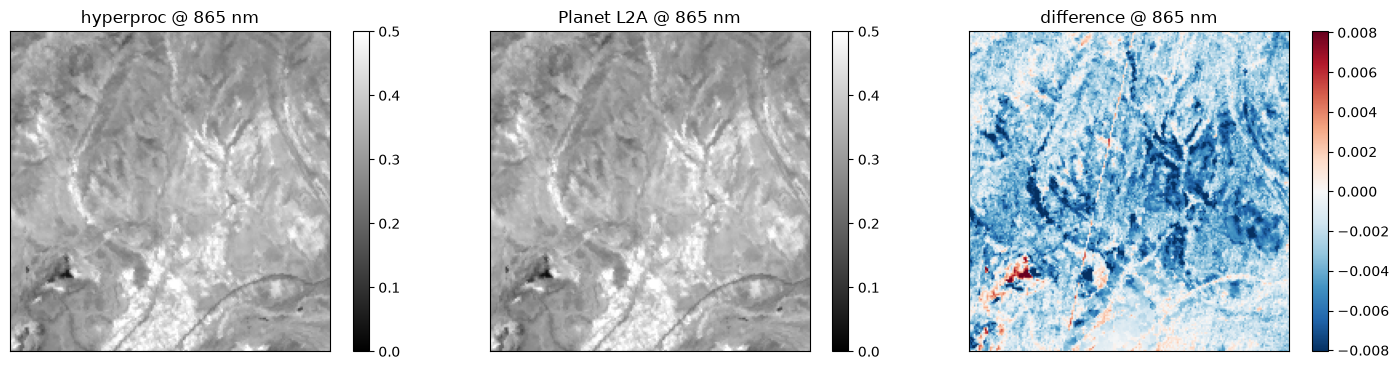

In [14]:
if RUN_AC:
    with rasterio.open(ac["reflectance"]) as src:
        wl_ours = np.array([float(d.split()[0]) for d in src.descriptions])
        b = int(np.argmin(np.abs(wl_ours - DIAG_NM)))
        ours = src.read(b + 1)
    xs, ys = raster_grid(ac["reflectance"])          # line up by coordinate, never by index
    VAR = hp.main_var(l2)
    k = int(np.argmin(np.abs(l2.wavelength.values - DIAG_NM)))
    theirs = same_ground(l2[VAR].isel(wavelength=k), xs, ys).values

    ok = np.isfinite(ours) & np.isfinite(theirs) & (ours > 0) & (theirs > 0)
    print(f"our retrieval against the Planet L2A at {DIAG_NM:.0f} nm, {ok.sum():,} pixels:")
    if ok.sum() > 100:
        print(f"   median difference {np.median(ours[ok]-theirs[ok]):+.4f}"
              f"   RMSE {np.sqrt(np.mean((ours[ok]-theirs[ok])**2)):.4f}"
              f"   r {np.corrcoef(ours[ok], theirs[ok])[0,1]:.4f}")

    lim = float(np.nanpercentile(np.abs(ours - theirs), 98)) or 0.02
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    for a, img, t, kw in ((ax[0], ours, "hyperproc", dict(cmap="gray", vmin=0, vmax=0.5)),
                          (ax[1], theirs, "Planet L2A", dict(cmap="gray", vmin=0, vmax=0.5)),
                          (ax[2], ours-theirs, "difference", dict(cmap="RdBu_r", vmin=-lim, vmax=lim))):
        im = a.imshow(img, **kw); a.set_title(f"{t} @ {DIAG_NM:.0f} nm"); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout(); plt.show()

### 3.2 BRDF normalisation, and the whole chain in one call

A satellite sees each pixel once, so it cannot measure its own angular response. The
c-factor method borrows the shape from MODIS: for every 500 m cell MODIS publishes the
three weights of a kernel model fitted over the preceding sixteen days, and the correction
is the ratio of modelled reflectance at the target geometry to modelled reflectance at the
observed one. Only the ratio is used, so the absolute level of the MODIS retrieval cancels
and what transfers is the shape.

### `mcd43.fetch(...)`  (`hyperproc.correct.mcd43`)

Downloads and caches the MODIS parameters for a scene.

| Parameter | Default | What it does |
|---|---|---|
| `ds` | — | a dataset to take the footprint and date from, instead of passing them by hand |
| `bounds`, `date` | from `ds` | `(w, s, e, n)` in degrees and `YYYY-MM-DD`, if you would rather be explicit |
| `out_dir` | the shared cache | where the downloaded file goes. A second call with the same footprint reuses it |
| `res` | `None` | the grid step. `None` adapts to the image: never finer than MODIS's own 464 m, and coarser cells **averaged** when the image pixels are coarser |
| `days` | `8` | how far either side of the scene date to look if that day has no granule |
| `quality` | `True` | also fetch the per-band quality and snow flags |
| `project` | `None` | your Earth Engine Cloud project, if your credentials do not carry one |
| `overwrite` | `False` | re-download even when the cache has it |

### `hp.correct.nbar(ds, params=None, ...)`

| Parameter | Default | What it does |
|---|---|---|
| `params` | downloaded | the MODIS parameters. Pass a fetched object to avoid a second download |
| `sza_ref` | `45.0` | target solar zenith. A number is the usual NBAR convention; `"observed"` keeps each pixel's own sun and removes **only** the view effect, which never extrapolates the model in sun angle; `"mean"` uses the scene mean |
| `vza_ref`, `raa_ref` | `0.0`, `0.0` | target view geometry, nadir by default |
| `spectral` | `"nearest"` | `"nearest"` gives each band the closest MODIS band's factor, as published, at the cost of a step where the assignment switches. `"interp"` is smooth but applies a shape no MODIS band measured |
| `fill` | `"none"` | what to do where MODIS has no retrieval. `"none"` leaves the pixel untouched and flags it; `"median"` uses the scene median; `"nearest"` copies the nearest valid factor |
| `clip` | `(0.25, 4.0)` | bounds on the correction factor, which stop a near-zero modelled reflectance producing a wild ratio |
| `qa_max` | `3` | keep MODIS cells up to this quality. 3 keeps every retrieval, which is right here because a magnitude inversion scales all three weights together and that factor cancels in the ratio; `1` keeps full inversions only, at the cost of holes |
| `mask_snow` | `True` | drop cells MODIS flags as snow-covered |
| `keep_c` | `True` | attach the seven factors as a `c_factor` variable for inspection |
| `cache_dir`, `project` | | passed to the fetch when `params` is not given |

Adding `"brdf"` to `process(stages=...)` runs the whole chain in one call.

In [15]:
if RUN_BRDF:                      # scenario B needs these too, with or without step 3.1
    from hyperproc.correct import mcd43
    params = mcd43.fetch(ds=l2_sub, out_dir=MODIS_DIR, verbose=True)
    print(f"\nMODIS parameters {params.shape} at {abs(params.transform[0])*111320:.0f} m, "
          f"date {params.date}, {params.coverage()*100:.0f} % of cells retrieved")
else:
    params = None

  MCD43A1 [cached] MCD43A1_2025-05-03_70.0667_41.1542_43x38_240.00cpd.tif

MODIS parameters (38, 43) at 464 m, date 2025-05-03, 100 % of cells retrieved


In [16]:
if RUN_AC and RUN_BRDF:
    t0 = time.time()
    acb = process(l1_path, OUT / "03_ac_brdf", work_dir=WORK_DIR, stages=("ac", "brdf"),
                  workers=WORKERS, window=WINDOW, format=EXPORT_FORMAT, overviews=True,
                  brdf=dict(params=params, sza_ref=SZA_REF, vza_ref=VZA_REF,
                            spectral=SPECTRAL_MAP, fill="none"), verbose=True)
    print(f"\n{(time.time()-t0)/60:.1f} min -> {Path(acb['reflectance']).name}")
    print("   the retrieval was reused from the work directory; only the BRDF step and the export ran")
else:
    acb = None; print("skipped")

process: 20250503_064345_16_4001_ortho_radiance  stages ('ac', 'brdf')  engine sRTMnet  work /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit


dem: elev 853..2047 m from Copernicus DEM GLO-30 (EGM2008), bilinear
prepare_inputs: TANAGER -> apply_oe sensor tanager, fid 20250503_064345_tanager; 200 x 200 x 426
  radiance file already present with the right size; kept


ISOFIT inputs for 20250503_064345_16_4001_ortho_radiance  (sensor code tanager, fid 20250503_064345_tanager)
  200 lines x 200 samples x 426 bands, radiance x0.1 -> uW/cm2/nm/sr
  rdn /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/input/20250503_064345_tanager_rdn
  loc /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/input/20250503_064345_tanager_loc
  obs /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/input/20250503_064345_tanager_obs
  valid pixels 100.0%; lat 41.076 lon 70.156 elev 853..2047 m
  sza 26.2..26.3  vza 5.9..6.8  raa 60..67 deg  utc 6.729 h
reflectance product already present: /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/02_ac/isofit/output/20250503_064345_tanager_rfl (overwrite=True to redo)
BRDF c-factor on reflectance {'y': 200, 'x': 200, 'wavelength': 426}: sza 26.3 deg, vza 5.9-6.8 deg


  MODIS parameters at 100.0 % of the 100 % of cells the sensor observed; c-factor median 0.8707 (band 2 0.9202)


writing 20250503_064345_16_4001_ortho_radiance_ac_brdf_win230-430_290-490.tif  ({'wavelength': 426, 'x': 200, 'y': 200}) ...


/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/home/fujiang/miniconda3/envs/hsi/lib/python3.12/site-packages/rioxarray/_io.py:1148: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identit

quality: cloud 0.2%, clear 99.8%
done in 0.1 min -> /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/03_ac_brdf/20250503_064345_16_4001_ortho_radiance_ac_brdf_win230-430_290-490.tif

0.1 min -> 20250503_064345_16_4001_ortho_radiance_ac_brdf_win230-430_290-490.tif
   the retrieval was reused from the work directory; only the BRDF step and the export ran


### 3.3 You already have `*_ac.tif`. Going on from there.

This is the common case: the retrieval ran days ago, the product is on disk, and you now
want the BRDF version without spending another hour.

Two things stand in the way, and both are worth understanding rather than working around.

**`hp.open` will not read a product back.** The readers identify granules by their
provider's naming, and a file this package wrote is not one. Try it and you get a clear
refusal rather than a wrong answer. So a product is read with `rasterio`, and the
wavelengths come from the band descriptions in a GeoTIFF or from the `wavelength` field in
an ENVI header, which is one concrete reason to prefer ENVI for intermediate products.

**The product carries no angles.** `process` writes the reflectance cube, the retrieved
aerosol and water-vapour layers and the quality flags, but not the per-pixel geometry, and
the BRDF step needs `sza`, `vza` and `raa`. You have two ways to supply them:

1. re-open the source granule, which is on the same grid;
2. or write them at correction time with `hp.export_geometry`, as step 2 did, so they are
   beside the product.

The helper below does the first. It is short on purpose: the point is to show what a
product is, not to hide it.

**The two routes agree, but not bit for bit, and the reason is worth knowing.** Where
MODIS has no retrieval, `fill="none"` leaves a pixel untouched. The two routes sample the
464 m MODIS grid at slightly different points, so along the ragged edge of MODIS coverage
a pixel can be corrected by one route and left alone by the other. The median difference
is a hundredth of a percent of reflectance; a small tail of pixels differs by more. Use
`fill="nearest"` if you need the two routes to track each other closely.

In [17]:
def load_product(path, geometry_from=None, var="reflectance", bands=None):
    '''Read a product this package wrote back into a dataset the corrections accept.

    path          a *_ac.tif or *_ac.img written by process() or to_raster()
    geometry_from an opened granule on the same grid, to take sza/vza/raa from.
                  None returns the cube alone, which is enough for the spectral tools
                  but not for a BRDF correction.
    bands         None reads every band; a list of 0-based indices reads only those.
    '''
    with rasterio.open(path) as src:
        envi = src.tags(ns="ENVI")
        if "wavelength" in envi:                       # ENVI states them as numbers
            wl = np.array([float(v) for v in envi["wavelength"].strip("{}").split(",")])
        else:                                          # GeoTIFF: parse the band labels
            wl = np.array([float(d.split()[0]) for d in src.descriptions])
        idx = list(range(src.count)) if bands is None else list(bands)
        cube = src.read([i + 1 for i in idx]).astype("float32")
        wl = wl[idx]
        tr, crs = src.transform, str(src.crs)
        ny, nx = src.height, src.width
    ds = xr.Dataset(
        {var: (("y", "x", "wavelength"), np.moveaxis(cube, 0, -1))},
        coords={"wavelength": wl,
                "x": tr.c + (np.arange(nx) + 0.5) * tr.a,
                "y": tr.f + (np.arange(ny) + 0.5) * tr.e},
        attrs={"crs": crs, "transform": tuple(tr.to_gdal()), "sensor": "TANAGER",
               "stem": Path(path).stem, "units": "1"})
    if geometry_from is not None:
        g = same_ground(geometry_from, ds.x.values, ds.y.values)   # by coordinate, not by index
        for layer in ("sza", "saa", "vza", "vaa", "raa"):
            if layer in g:
                ds[layer] = (("y", "x"), np.asarray(g[layer].values, dtype="float32"))
    return ds


# hp.open refuses a product, on purpose and with an explanation
if RUN_AC:
    try:
        hp.open(ac["reflectance"])
    except ValueError as exc:
        print("hp.open on a product:", str(exc)[:96], "...")

hp.open on a product: Cannot tell what '20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490.tif' is. Pass sen ...


In [18]:
if RUN_AC and RUN_BRDF:
    geom = l2
    saved = load_product(ac["reflectance"], geometry_from=geom)
    print(f"loaded {Path(ac['reflectance']).name}")
    print(f"   {dict(saved.sizes)}  {saved.wavelength.values.min():.0f}-{saved.wavelength.values.max():.0f} nm")
    print(f"   geometry attached: {[v for v in ('sza','vza','raa') if v in saved]}")

    from_saved = hp.correct.nbar(saved, params=params, sza_ref=SZA_REF, vza_ref=VZA_REF,
                                 spectral=SPECTRAL_MAP, fill="none", verbose=False)
    slim = from_saved.drop_vars([v for v in ("c_factor", "modis_band") if v in from_saved.variables])
    p = hp.to_raster(slim, OUT / "03b_from_saved_ac" / f"{Path(ac['reflectance']).stem}_brdf{EXT}",
                     format=EXPORT_FORMAT, **({"overviews": True} if EXPORT_FORMAT == "GTiff" else {}))
    print(f"\nwrote {p.name}")

    # the two routes agree, but not to the last bit - see the note above
    with rasterio.open(acb["reflectance"]) as src:
        wl_c = np.array([float(d.split()[0]) for d in src.descriptions])
        bi = int(np.argmin(np.abs(wl_c - DIAG_NM)))
        chained = src.read(bi + 1)
    xs_c, ys_c = raster_grid(acb["reflectance"])
    two_step = same_ground(from_saved.reflectance.isel(
        wavelength=int(np.argmin(np.abs(from_saved.wavelength.values - DIAG_NM)))), xs_c, ys_c).values
    ok = np.isfinite(chained) & np.isfinite(two_step) & (chained > 0.01)
    d = chained[ok] - two_step[ok]
    print(f"\nagainst the one-call chain at {DIAG_NM:.0f} nm, {ok.sum():,} pixels:")
    print(f"   median difference {np.median(d):+.2e}   p99 |d| {np.percentile(np.abs(d), 99):.2e}"
          f"   max |d| {np.abs(d).max():.2e}")
    print(f"   as a fraction of reflectance: median {np.median(np.abs(d)/chained[ok])*100:.3f} %"
          f"   max {(np.abs(d)/chained[ok]).max()*100:.2f} %")

loaded 20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490.tif
   {'y': 200, 'x': 200, 'wavelength': 426}  376-2499 nm
   geometry attached: ['sza', 'vza', 'raa']



wrote 20250503_064345_16_4001_ortho_radiance_ac_win230-430_290-490_brdf.tif

against the one-call chain at 865 nm, 40,000 pixels:
   median difference +0.00e+00   p99 |d| 0.00e+00   max |d| 0.00e+00
   as a fraction of reflectance: median 0.000 %   max 0.00 %


## Step 4 — scenario B, starting from L2A reflectance

If you already have surface reflectance, the atmospheric stage is done and you go straight
to the geometric one. `hp.correct.nbar` is the same function step 3.2 used through
`process`, called directly on any dataset that carries reflectance and per-pixel angles.
Its parameters are the table in step 3.2.

The result is lazy, so nothing is computed until it is written.

In [19]:
if RUN_BRDF:
    t0 = time.time()
    l2_brdf = hp.correct.nbar(l2_sub, params=params, sza_ref=SZA_REF, vza_ref=VZA_REF,
                              spectral=SPECTRAL_MAP, fill="none", cache_dir=MODIS_DIR)
    print(f"built in {time.time()-t0:.1f} s (lazy); stem -> {l2_brdf.attrs['stem']}")
    for k, v in l2_brdf.attrs.items():
        if k.startswith("brdf_"):
            print(f"   {k:24s} {v}")

BRDF c-factor on reflectance {'y': 200, 'x': 200, 'wavelength': 426}: sza 26.3 deg, vza 5.9-6.8 deg


  MODIS parameters at 100.0 % of the 100 % of cells the sensor observed; c-factor median 0.8707 (band 2 0.9202)


built in 0.1 s (lazy); stem -> 20250503_064345_16_4001_ortho_sr_brdf
   brdf_method              c-factor (Roy et al. 2016) with MODIS MCD43A1 kernel weights
   brdf_kernels             ross_thick+li_sparse_r (b_r=1.0, h_b=2.0)
   brdf_target              sza=45 vza=0 raa=0
   brdf_spectral            nearest
   brdf_fill                none
   brdf_sampling            bilinear
   brdf_clip                0.25-4.0
   brdf_quality             qa_max=3 mask_snow=True
   brdf_parameters          /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window/03_ac_brdf/mcd43/MCD43A1_2025-05-03_70.0667_41.1542_43x38_240.00cpd.tif
   brdf_parameter_date      2025-05-03
   brdf_parameter_step_m    464
   brdf_coverage            1.0000
   brdf_unobserved          0.0000


In [20]:
if RUN_BRDF:
    slim = l2_brdf.drop_vars([v for v in ("c_factor", "modis_band") if v in l2_brdf.variables])

    export_ds = for_export(slim)               # projects a swath, passes a grid through
    if export_ds is not slim:
        print(f"georeferenced {dict(slim.sizes)} -> {dict(export_ds.sizes)}")
    t0 = time.time()
    p = hp.to_raster(export_ds, OUT / "04_l2_brdf" / f"{l2_brdf.attrs['stem']}{EXT}",
                     format=EXPORT_FORMAT, **({"overviews": True} if EXPORT_FORMAT == "GTiff" else {}))
    hp.bands_to_csv(export_ds, OUT / "04_l2_brdf" / f"{l2_brdf.attrs['stem']}_bands.csv")
    print(f"wrote {p.name} ({p.stat().st_size/1e9:.3f} GB) in {(time.time()-t0)/60:.1f} min")

wrote 20250503_064345_16_4001_ortho_sr_brdf.tif (0.058 GB) in 0.1 min


median change at 865 nm: -7.98 %


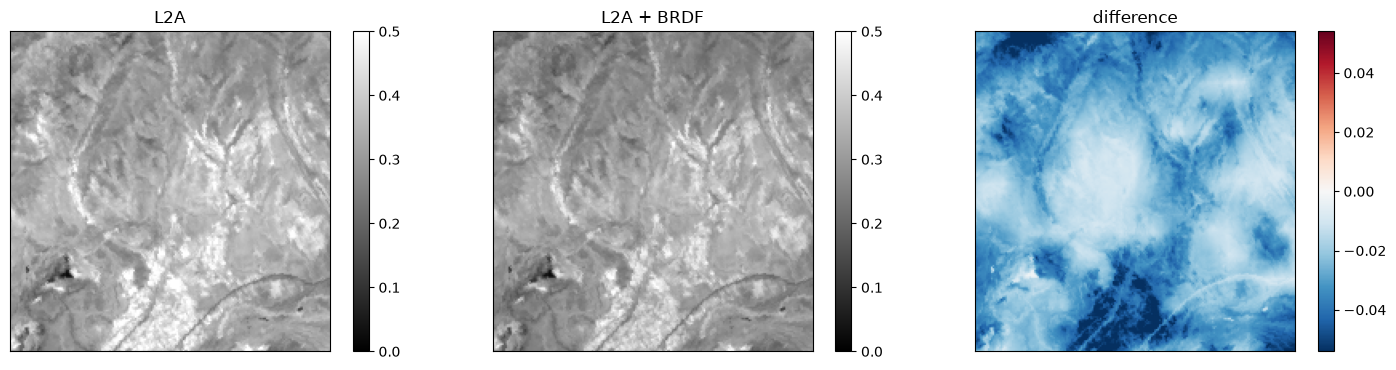

In [21]:
if RUN_BRDF:
    VAR = hp.main_var(l2_sub)
    b = int(np.argmin(np.abs(l2_sub.wavelength.values - DIAG_NM)))
    before = np.asarray(l2_sub[VAR].isel(wavelength=b).values, dtype="float32")
    after = np.asarray(l2_brdf[VAR].isel(wavelength=b).values, dtype="float32")
    ok = np.isfinite(before) & np.isfinite(after) & (before > 0.01)
    print(f"median change at {DIAG_NM:.0f} nm: {np.median((after[ok]-before[ok])/before[ok])*100:+.2f} %")
    lim = float(np.nanpercentile(np.abs(after - before), 98)) or 0.05
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    for a, img, t, kw in ((ax[0], before, "L2A", dict(cmap="gray", vmin=0, vmax=0.5)),
                          (ax[1], after, "L2A + BRDF", dict(cmap="gray", vmin=0, vmax=0.5)),
                          (ax[2], after-before, "difference", dict(cmap="RdBu_r", vmin=-lim, vmax=lim))):
        im = a.imshow(img, **kw); a.set_title(t); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout(); plt.show()

### Can this scene check its own BRDF correction?

Two diagnostics, and it matters which one a scene can carry.

### `cfactor.view_profile(before, after=None, wavelength=865, var=None, step=2, stride=1, ndvi=None)`

Bins the scene by view zenith and reports the mean reflectance per bin and the linear
slope, before and after. Its trap is that view zenith is also a **position**, so the
profile is partly a transect over changing land cover; `ndvi=(0.2, 0.4)` holds vegetation
density roughly constant, which helps but does not cure it. `step` is the bin width in
degrees and `stride` subsamples to keep the read cheap.

### `cfactor.model_agreement(ds, params, wavelength=865, ndvi=(0.2, 0.5), vza_range=None, step=20, stride=1, min_count=200)`

The one that goes to the heart of the method. It bins pixels by relative azimuth, from the
hotspot at 0 degrees to forward scattering at 180, and asks whether the observed
reflectance rises and falls the way the borrowed MODIS parameters predict. It repeats the
comparison with the azimuth turned by 180 degrees, which is a sharp check on the one input
a reader can plausibly get backwards.

Expect `inconclusive` here. Tanager is a narrow-swath instrument, so it does not span enough angle to separate the angular signal from the landscape. That is the correct answer, not a failure: on PACE, whose swath crosses a continent, the same test returns a verdict.

With a small `WINDOW` there is even less to work with, and both diagnostics may refuse
outright rather than return a weak number. Refusing is the right behaviour: run the whole
scene if you want these to mean anything.

In [22]:
if RUN_BRDF:
    from hyperproc.correct import cfactor
    try:
        prof = cfactor.view_profile(l2_sub, l2_brdf, wavelength=DIAG_NM, step=0.25, stride=3)
        print(f"view-angle slope at {DIAG_NM:.0f} nm: {prof['slope_before']*1000:+.3f} -> "
              f"{prof['slope_after']*1000:+.3f} e-3 per degree over {prof['vza_span']:.2f} deg")
    except ValueError as exc:
        print("view profile not available:", exc)
    try:
        agree = cfactor.model_agreement(l2_sub, params.masked(), wavelength=DIAG_NM, stride=2)
        print(f"\nmodel agreement: r={agree['r']:+.3f}, flipped={agree['r_flipped']:+.3f}, "
              f"{agree['azimuth_span']:.0f} deg of azimuth in {len(agree['raa'])} bins")
        print("  ->", agree["verdict"])
    except ValueError as exc:
        print("\nmodel agreement: not testable -", exc)

view-angle slope at 865 nm: -58.847 -> -64.920 e-3 per degree over 0.94 deg



model agreement: not testable - only 1 azimuth bins have 200+ pixels; this scene does not span enough azimuth to test the shape


## Step 5 — the quality layer

Every provider names its masks differently. Nine spellings mean cloud across the sensors
this package reads, shadow is `shadow` on one instrument and `cloudshadow` on another, and
`valid` and `nodata` mean opposite things. One layer with documented bits makes masking
the same call whatever the instrument.

### `hp.quality_flags(ds, var=None, derive=("fill", "terrain_shadow"), negative_fraction=0.1, slope_max=45.0, zhai=False, sources=True, verbose=False)`

| Parameter | Default | What it does |
|---|---|---|
| `derive` | `("fill", "terrain_shadow")` | flags to compute rather than read. `"fill"` marks pixels with no finite value in any usable band, `"terrain_shadow"` needs `cos_i`, `"steep_terrain"` needs `slope`, `"negative_reflectance"` reads the cube |
| `negative_fraction` | `0.1` | fraction of usable bands that must be below zero before `negative_reflectance` is set |
| `slope_max` | `45.0` | degrees above which `steep_terrain` is set |
| `zhai` | `False` | also run a spectral cloud index where the bands exist. Off by default: a provider that ships a cloud mask should be trusted over it |
| `sources` | `True` | read the provider's own layers. `False` derives only |

### `hp.quality_apply(ds, quality=None, drop=("fill", "cloud", "cloud_shadow", "cirrus"), var=None, keep=True, derive=("fill",))`

Sets the cube to NaN wherever a dropped flag is set. `drop` is the list of flags to mask
on, and `keep` attaches the layer to the result.

### `hp.quality_decode(quality, *names)` and `hp.quality_table(quality)`

`decode` returns a boolean for any combination of flags; `table` prints the bit meanings
with the share of pixels carrying each. `process` writes this layer beside every product
automatically.

In [23]:
q = hp.quality_flags(l2_sub, derive=("fill", "terrain_shadow"))
print(hp.quality_table(q))

bit  flag                  share    meaning
---  --------------------  -------  ----------------------------------------------
  0  fill                    0.00 %  no observation (off-swath, nodata, navigation failure)
  1  saturated               0.00 %  a band is at the detector rail
  2  cloud                   0.17 %  opaque cloud
  3  cloud_shadow            0.00 %  shadow cast by cloud
  4  cirrus                  0.00 %  thin or high cloud
  5  snow_ice                0.00 %  snow or ice
  6  water                   0.00 %  inland or ocean water
  7  haze                    0.00 %  aerosol haze flagged by the provider
  8  sun_glint               0.00 %  specular reflection geometry
  9  terrain_shadow          0.00 %  not illuminated by the direct beam (cos i <= 0)
 10  steep_terrain           0.00 %  slope beyond what a topographic correction holds
 11  ac_failed               0.00 %  atmospheric correction did not converge
 12  brdf_filled             0.00 %  BRDF c-factor no

/tmp/ipykernel_1989396/3775921341.py:1: UserWarning: quality: cannot derive 'terrain_shadow' without cos_i
  q = hp.quality_flags(l2_sub, derive=("fill", "terrain_shadow"))


after masking cloud, shadow, cirrus and fill: 99.8 % of the grid still carries data


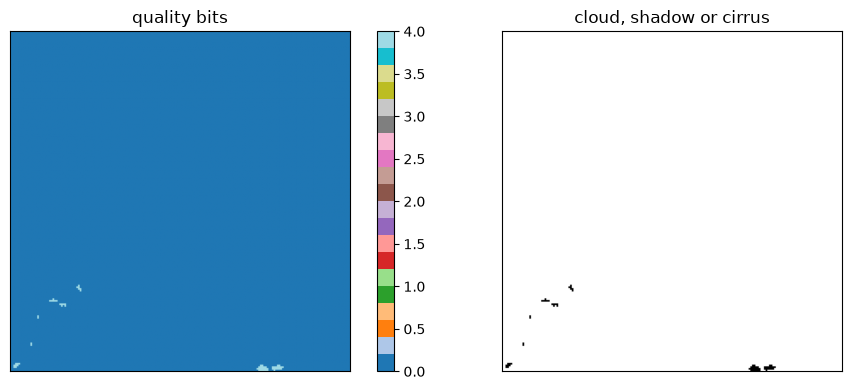

In [24]:
clear = hp.quality_apply(l2_sub, q, drop=("fill", "cloud", "cloud_shadow", "cirrus"))
VAR = hp.main_var(l2_sub)
kept = np.isfinite(clear[VAR].isel(wavelength=l2_sub.sizes["wavelength"] // 2).values).mean()
print(f"after masking cloud, shadow, cirrus and fill: {kept*100:.1f} % of the grid still carries data")

# write the flag layer on its own, so a swath does not drag the whole cube through georeference
qds = xr.Dataset({"quality": q}, attrs=dict(l2_sub.attrs))
for _v in ("lat", "lon"):
    if _v in l2_sub:
        qds[_v] = l2_sub[_v]
hp.to_geotiff_2d(for_export(qds), OUT / "05_quality" / f"quality{EXT}", var="quality",
                 format=EXPORT_FORMAT, overview_resampling="nearest",
                 tags={"flag_bits": q.attrs["flag_bits"], "flag_meanings": q.attrs["flag_meanings"]})

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(q.values, cmap="tab20"); ax[0].set_title("quality bits")
plt.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].imshow(hp.quality_decode(q, "cloud", "cloud_shadow", "cirrus").values, cmap="gray_r")
ax[1].set_title("cloud, shadow or cirrus")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## Step 6 — post-processing

Everything from here takes a corrected cube and either transforms it, a cube in and a cube
out, in `hyperproc.spectral`, or reduces it to a map, in `hyperproc.features`.

### 6.1 Two smoothers, with opposite contracts

### `hp.smooth_spectra(ds, var=None, window=5, order=2, method="savgol", good_only=True)`

| Parameter | Default | What it does |
|---|---|---|
| `window` | `5` | filter length in bands. Must be odd and greater than `order` |
| `order` | `2` | polynomial order of the local fit |
| `method` | `"savgol"` | Savitzky-Golay, which keeps peak shape, or `"moving"` for a running mean |
| `good_only` | `True` | smooth only within runs of usable bands, so the filter **never reaches across a gap**. With `False` the whole spectrum is one run |

It is cosmetic: it removes the band-to-band structure a per-pixel retrieval leaves. It
cannot invent a value and it preserves the NaN pattern exactly.

### `hp.spline_gapfill(ds, var=None, df=60, threshold=0.018, despike=True, exclude=..., mask_after=..., min_points=20, keep_fill_flag=True)`

The opposite, on purpose. Four steps per spectrum: remove upward spikes, blank the regions
where the instrument's spectral shift leaves artefacts, fit a smoothing spline through what
survives and evaluate it **everywhere**, then blank the deep water absorptions.

| Parameter | Default | What it does |
|---|---|---|
| `df` | `60` | degrees of freedom for the spline. Higher follows the spectrum more closely |
| `threshold` | `0.018` | how far a spike must rise above its neighbours, in reflectance |
| `despike` | `True` | run the spike removal at all |
| `exclude` | 13 windows | blanked **before** the fit, so the spline interpolates across them |
| `mask_after` | 3 windows | blanked **after** the fit, so what it discards was interpolated anyway |
| `min_points` | `20` | a spectrum with fewer surviving bands is left as NaN |
| `keep_fill_flag` | `True` | attach `spline_filled`, marking which reported bands are interpolation rather than measurement |

This reproduces a published R pipeline; the spline is a port of R's `smooth.spline`,
verified against R to about 1e-8. Because it invents values, the flag matters.

The figure below shows something the description does not. Between a window excluded
before the fit and one masked after it, the spline is unconstrained by any data, so it
can swing well away from the spectrum for a few bands before the mask hides it. That is
the R pipeline's own behaviour, reproduced faithfully, and a reason to trust
`spline_filled` rather than the curve.

**Fit narrow features on the unsmoothed cube.** Both of these bias exactly the absorption
depths and index ratios that 6.2 and 6.3 measure.

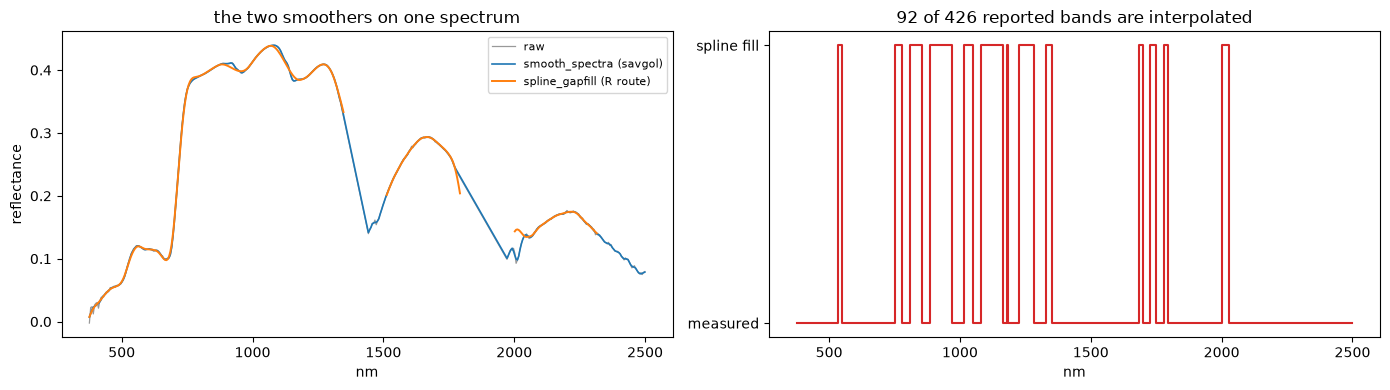

In [25]:
if RUN_POST:
    patch = l2_sub.isel(y=slice(_cy - 20, _cy + 20), x=slice(_cx - 20, _cx + 20))
    VAR = hp.main_var(patch)
    sg = hp.smooth_spectra(patch, window=7, order=2, method="savgol", good_only=True)
    sp = hp.spline_gapfill(patch, df=60, threshold=0.018, despike=True)
    wl = patch.wavelength.values
    good = (patch.good_wavelength.values.astype(bool) if "good_wavelength" in patch.coords
            else np.ones(wl.size, bool))
    y, x = 20, 20
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(wl[good], patch[VAR].isel(y=y, x=x).values[good], color="0.6", lw=0.9, label="raw")
    ax[0].plot(wl[good], sg[VAR].isel(y=y, x=x).values[good], lw=1.2, label="smooth_spectra (savgol)")
    ax[0].plot(wl, sp[VAR].isel(y=y, x=x).values, lw=1.4, label="spline_gapfill (R route)")
    ax[0].legend(fontsize=8); ax[0].set_xlabel("nm"); ax[0].set_ylabel("reflectance")
    ax[0].set_title("the two smoothers on one spectrum")
    filled = sp["spline_filled"].isel(y=y, x=x).values
    ax[1].plot(wl, filled.astype(int), drawstyle="steps-mid", color="tab:red")
    ax[1].set_yticks([0, 1]); ax[1].set_yticklabels(["measured", "spline fill"])
    ax[1].set_xlabel("nm"); ax[1].set_title(f"{filled.sum()} of {wl.size} reported bands are interpolated")
    plt.tight_layout(); plt.show()

### 6.2 Continuum removal, derivatives and absorption depth

### `hp.continuum_removal(ds, var=None, window=None, good_only=True)`

Divides each spectrum by its upper convex hull, which separates the shape of an absorption
from the brightness of the surface under it. `window=(2000, 2300)` restricts the hull to a
feature, which is usually what you want; `None` fits the whole spectrum.

### `hp.spectral_derivative(ds, var=None, order=1, window=7, poly=2, good_only=True)`

| Parameter | Default | What it does |
|---|---|---|
| `order` | `1` | 1 for the first derivative, 2 for the second |
| `window`, `poly` | `7`, `2` | the local polynomial fit. Differentiating raw reflectance amplifies noise, so the derivative comes from a fit rather than finite differences |

### `hp.band_depth(ds, feature, var=None, good_only=True)`

`feature` is a name from the built-in list (`"chlorophyll"`, `"water_970"`, `"water_1200"`,
`"lignin_1730"`, `"cellulose"`, `"clay_2200"`) or a `(lo, hi)` window in nm. Returns
`depth`, `position` and `area`. Depth is measured against the feature's own shoulders,
which is what makes it comparable between scenes.

**Tanager can use `"cellulose"` here.** It covers the full range, so any of them works.

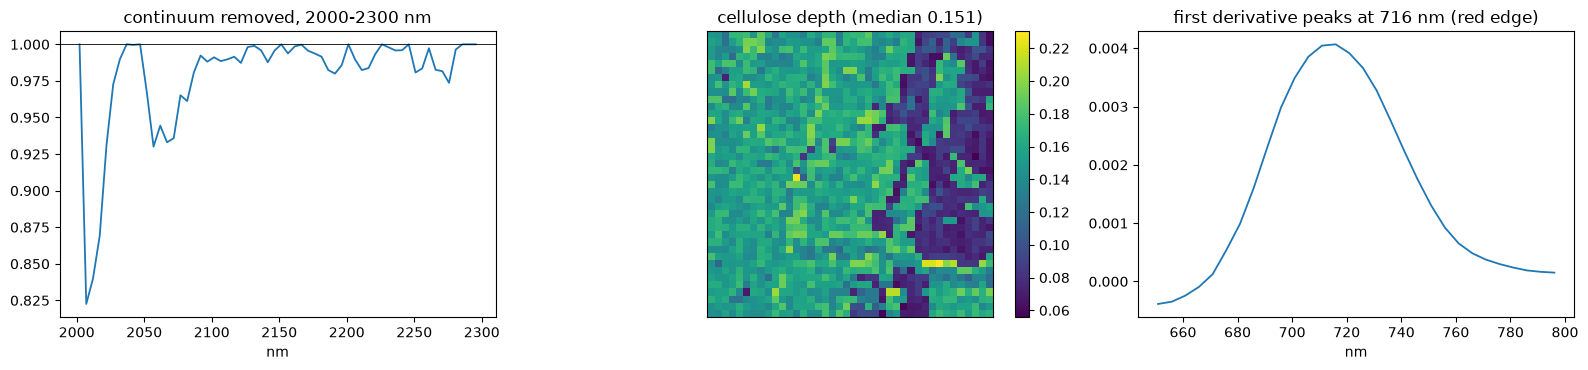

In [26]:
if RUN_POST:
    cr = hp.continuum_removal(patch, window=(2000, 2300))
    bd = hp.band_depth(patch, "cellulose")
    d1 = hp.spectral_derivative(patch, order=1, window=7, poly=2)
    wl = patch.wavelength.values
    inside = (wl >= 2000) & (wl <= 2300)
    fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
    ax[0].plot(wl[inside], cr[VAR].isel(y=20, x=20).values[inside], lw=1.3)
    ax[0].axhline(1, color="k", lw=0.6); ax[0].set_title("continuum removed, 2000-2300 nm"); ax[0].set_xlabel("nm")
    im = ax[1].imshow(bd["depth"].values, cmap="viridis"); plt.colorbar(im, ax=ax[1], fraction=0.046)
    ax[1].set_title(f"cellulose depth (median {np.nanmedian(bd['depth'].values):.3f})")
    ax[1].set_xticks([]); ax[1].set_yticks([])
    prof = np.nanmedian(d1[VAR].values.reshape(-1, wl.size), axis=0)
    vis = (wl > 650) & (wl < 800)
    if vis.sum() > 3:
        ax[2].plot(wl[vis], prof[vis], lw=1.3)
        ax[2].set_title(f"first derivative peaks at {wl[vis][np.nanargmax(prof[vis])]:.0f} nm (red edge)")
    ax[2].set_xlabel("nm")
    plt.tight_layout(); plt.show()

### 6.3 Spectral indices

### `hp.spectral_index(ds, formula, var=None, tolerance=20.0, good_only=True, name=None)`

| Parameter | Default | What it does |
|---|---|---|
| `formula` | — | a name from the registry (`"NDVI"`), or an expression in which `R<wavelength>` means the band nearest that wavelength in nm, for example `"(R800 - R670) / (R800 + R670)"` |
| `tolerance` | `20.0` | how far, in nm, the nearest band may sit from the one you asked for before the call fails. The error message names the sensor's coverage |
| `good_only` | `True` | ignore bands flagged unusable |
| `name` | the index name | what to call the result |

Indices are addressed by **wavelength**, never by band number, which is why one call runs
unchanged on Tanager and on every other sensor the package reads.
Arithmetic and the functions `log`, `log10`, `sqrt`, `exp` and `abs` are allowed and
nothing else, so a formula pasted from a paper is safe.

### `hp.describe_indices(ds=None, tolerance=20.0)`

The twelve built-in indices with their formulas and citations, and, when given a dataset,
which of them that sensor can actually compute. 

In [27]:
if RUN_POST:
    print(hp.describe_indices(l2_sub))

index   status     formula                                                    reference
------- ---------- ---------------------------------------------------------- ------------------------
NDVI    available  (R860 - R660) / (R860 + R660)                              Rouse et al. 1974
EVI     available  2.5 * (R860 - R660) / (R860 + 6*R660 - 7.5*R480 + 1)       Huete et al. 2002
NDWI    available  (R860 - R1240) / (R860 + R1240)                            Gao 1996
NDII    available  (R820 - R1650) / (R820 + R1650)                            Hunt and Rock 1989
PRI     available  (R531 - R570) / (R531 + R570)                              Gamon et al. 1992
NDNI    available  (log(1/R1510) - log(1/R1680)) / (log(1/R1510) + log(1/R1680)) Serrano et al. 2002
CAI     available  0.5 * (R2020 + R2220) - R2100                              Nagler et al. 2003
MCARI   available  ((R700 - R670) - 0.2 * (R700 - R550)) * (R700 / R670)      Daughtry et al. 2000
ARI1    available  1/R550 - 1/R700      

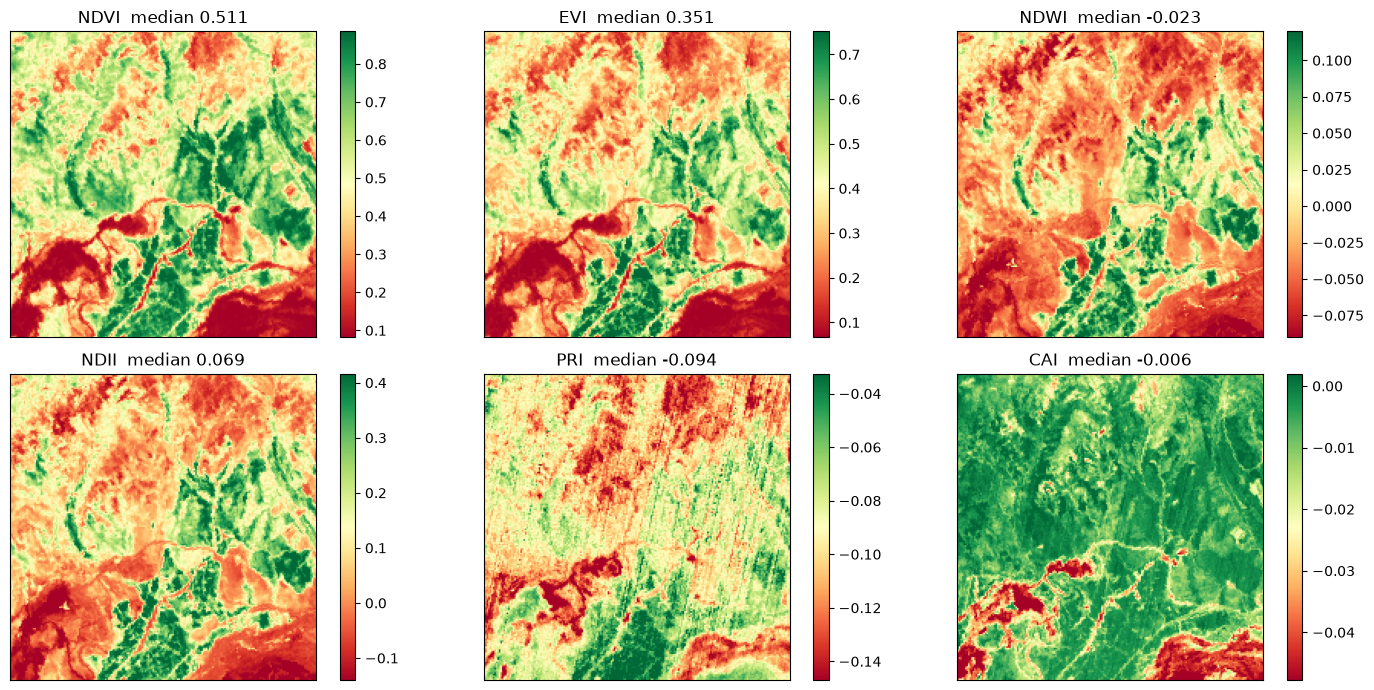

your own formula: (R800 - R670) / (R800 + R670)
bands it used   : R670=670.87 nm, R800=801.12 nm


In [28]:
if RUN_POST:
    names = ["NDVI", "EVI", "NDWI", "NDII", "PRI", "CAI"]
    ncol = 3; nrow = int(np.ceil(len(names) / ncol))
    fig, ax = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.5 * nrow))
    for a, n in zip(np.atleast_1d(ax).ravel(), names):
        v = hp.spectral_index(l2_sub, n).values
        im = a.imshow(v, cmap="RdYlGn", vmin=np.nanpercentile(v, 2), vmax=np.nanpercentile(v, 98))
        a.set_title(f"{n}  median {np.nanmedian(v):.3f}"); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)
    for a in np.atleast_1d(ax).ravel()[len(names):]: a.axis("off")
    plt.tight_layout(); plt.show()

    custom = hp.spectral_index(l2_sub, "(R800 - R670) / (R800 + R670)", name="my_ndvi")
    print("your own formula:", custom.attrs["formula"])
    print("bands it used   :", custom.attrs["bands_used"])

### 6.4 Resampling to another instrument

### `hp.resample(data, ...)`

Resampling is one matrix, so a whole scene moves in seconds. Name the target **one** of
four ways:

| Parameter | What it means |
|---|---|
| `step`, `fwhm`, `wl_range` | a regular grid: `step=10, fwhm=15` is 10 nm spacing with 15 nm bands |
| `wavelengths`, `fwhm` | explicit band centres and widths |
| `like=other_ds` | match another dataset's bands, using Gaussians of its stated FWHM |
| `sensor="SENTINEL2A"` | a real instrument, using the agency's **measured** response, downloaded and cached |

**Spacing and bandwidth are different things**, which is why `step` and `fwhm` are separate
arguments: every hyperspectral sensor here is oversampled.

| Parameter | Default | What it does |
|---|---|---|
| `method` | `None` | `None` lets a `sensor=` target use its measured response and otherwise uses `"gaussian"`. `"box"` reproduces Spectral Python's resampler; `"linear"`, `"cubic"`, `"nearest"` interpolate at the centres and ignore bandwidth |
| `min_coverage` | `0.5` | a target band with less than this fraction of its response inside the source's range comes back NaN **instead of being renormalised** over whatever bands happened to be there |
| `allow_sharpening` | `False` | asking for bands narrower than the source has is refused, because resampling cannot raise spectral resolution |
| `good_only` | `True` | exclude bands flagged unusable from the convolution and from the coverage |
| `return_coverage` | `False` | also return the per-band coverage fraction |



Watch which target bands come back NaN below. A target band sitting in a gap the source does not measure is dropped rather than invented.

### `srf.available()` and `srf.fetch(sensor, cache=None, overwrite=False, verbose=True)`

What response functions are known and which are already cached. Sentinel-2 comes from ESA,
Landsat 4 through 9 from the USGS; PlanetScope is listed as *nominal*, meaning published
band edges rather than a measured curve, and the entry says so rather than letting you
assume.

In [29]:
if RUN_POST:
    from hyperproc.spectral import srf
    print(srf.available())

sensor         kind      bands  cached  source
-------------- --------- -----  ------- ----------------------------------------
SENTINEL2A     measured     13  yes     ESA
SENTINEL2B     measured      -  no      ESA
LANDSAT4       measured      -  no      USGS
LANDSAT5       measured      -  no      USGS
LANDSAT7       measured      -  no      USGS
LANDSAT8       measured      9  yes     USGS
LANDSAT9       measured      -  no      USGS
PLANETSCOPE4   nominal       4  n/a     Planet (band edges only)
PLANETSCOPE8   nominal       8  n/a     Planet (band edges only)


  Sentinel-2A MSI [cached] SENTINEL2A.npz


Sentinel-2A MSI    dropped for low coverage: ['B10']
  Landsat 8 OLI [cached] LANDSAT8.npz


Landsat 8 OLI      dropped for low coverage: ['Cirrus']


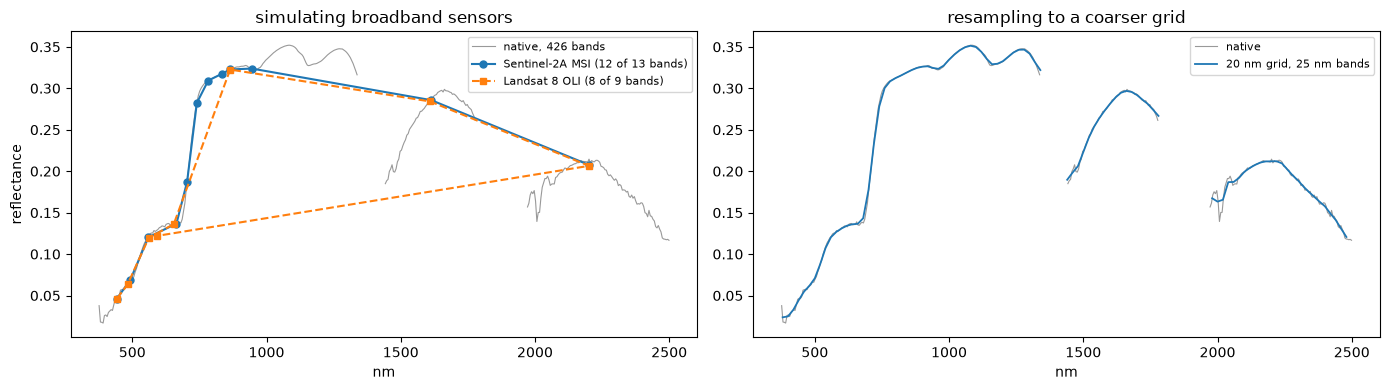


asking for 2 nm bands from a coarser instrument is refused:
   1061 target band(s) are narrower than the source: e.g. 378.0 nm asks for 2.00 nm from a source that measures 5.40 nm there. Resampling cannot raise sp ...


In [30]:
if RUN_POST:
    _h = min(50, _cy, _cx)
    patch2 = l2_sub.isel(y=slice(_cy - _h, _cy + _h), x=slice(_cx - _h, _cx + _h)).compute()
    VAR = hp.main_var(patch2)

    # bands the provider flags unusable carry a fill value, not a reflectance.
    # Blank them for the plot, exactly as good_only=True blanks them for the convolution.
    raw = np.asarray(patch2[VAR].values[_h // 2, _h // 2], dtype="float64").copy()
    if "good_wavelength" in patch2.coords:
        raw[~patch2.good_wavelength.values.astype(bool)] = np.nan
    wl2 = patch2.wavelength.values

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(wl2, raw, color="0.6", lw=0.8, label=f"native, {wl2.size} bands")
    for sensor, style in (("SENTINEL2A", "o-"), ("LANDSAT8", "s--")):
        try:
            out = hp.resample(patch2, sensor=sensor)
            got = srf.fetch(sensor, verbose=False)
            keep = np.isfinite(out[VAR].values[_h // 2, _h // 2])
            ax[0].plot(out.wavelength.values[keep], out[VAR].values[_h // 2, _h // 2][keep], style,
                       ms=5, label=f"{got['label']} ({keep.sum()} of {len(got['bands'])} bands)")
            print(f"{got['label']:18s} dropped for low coverage: "
                  f"{[b for b, kk in zip(got['bands'], keep) if not kk]}")
        except ValueError as exc:
            print(f"{sensor}: {str(exc)[:110]}")
    ax[0].legend(fontsize=8); ax[0].set_xlabel("nm"); ax[0].set_ylabel("reflectance")
    ax[0].set_title("simulating broadband sensors")

    grid = hp.resample(patch2, step=20, fwhm=25)
    ax[1].plot(wl2, raw, color="0.6", lw=0.8, label="native")
    ax[1].plot(grid.wavelength.values, grid[VAR].values[_h // 2, _h // 2], lw=1.3,
               label="20 nm grid, 25 nm bands")
    ax[1].legend(fontsize=8); ax[1].set_xlabel("nm"); ax[1].set_title("resampling to a coarser grid")
    plt.tight_layout(); plt.show()

    try:
        hp.resample(patch2, step=2, fwhm=2)
    except ValueError as exc:
        print("\nasking for 2 nm bands from a coarser instrument is refused:")
        print("  ", str(exc)[:150], "...")

## Step 7 — coregistration

Two products of the same ground rarely land on the same pixel, and cropping both to a
common extent aligns the corners while leaving the content offset.

### `hp.estimate_shift(moving, reference, wavelength=860, tiles=4, min_snr=3.0, max_scatter=1.0, var=None, ref_var=None, verbose=False)`

| Parameter | Default | What it does |
|---|---|---|
| `wavelength` | `860.0` | the band matched on. The near infrared has sharp land and water edges on almost every surface |
| `tiles` | `4` | the scene is matched in a `tiles x tiles` grid as well as whole, to see whether one shift describes it. `0` skips the check |
| `min_snr` | `3.0` | below this the correlation peak is not trusted |
| `max_scatter` | `1.0` | tiles must agree to within this many pixels for the result to count as consistent |

It returns the shift in pixels and in metres, the peak strength, the tile scatter, a
`consistent` verdict and a readable `report`. **A correlation peak always exists**, even
between unrelated images, which is why those last two matter.

### `hp.coregister(moving, reference, resample=False, force=False, ...)`

Measures and then corrects. By default it moves the georeferencing, which is exact and
free; `resample=True` puts the cube on the reference's own grid. It **refuses** an
inconsistent match unless you pass `force`.

Below it is used as a check rather than a correction: our own retrieval against
Planet's L2A. They cover the same ground and carry genuinely different radiometry,
so a correct matcher reports no shift with a strong peak. That is also the demonstration
that the method is insensitive to brightness differences between products.

In [31]:
if RUN_AC:
    with rasterio.open(ac["reflectance"]) as src:
        wl_p = np.array([float(d.split()[0]) for d in src.descriptions])
        bi = int(np.argmin(np.abs(wl_p - DIAG_NM)))
        n = min(500, src.width, src.height)      # a centred window, whatever size the product is
        win = rasterio.windows.Window((src.width - n) // 2, (src.height - n) // 2, n, n)
        arr = src.read(bi + 1, window=win); tr = src.window_transform(win); crs_p = str(src.crs)
    xs_a = tr.c + (np.arange(n) + 0.5) * tr.a
    ys_a = tr.f + (np.arange(n) + 0.5) * tr.e
    ours_ds = xr.Dataset({"reflectance": (("y", "x", "wavelength"), arr[:, :, None].astype("float32"))},
                         coords={"wavelength": [wl_p[bi]], "x": xs_a, "y": ys_a},
                         attrs={"crs": crs_p, "transform": tuple(tr.to_gdal()), "sensor": "TANAGER-AC"})
    ref = same_ground(l2, xs_a, ys_a)           # the same ground out of the provider's product
    fit = hp.estimate_shift(ours_ds, ref, wavelength=float(wl_p[bi]),
                            tiles=4 if n >= 200 else 2, verbose=False)
    print(f"matching a {n} x {n} window of our AC product against the Planet L2A\n")
    print(fit["report"])

matching a 200 x 200 window of our AC product against the Planet L2A

shift  +0.00 px down, +0.00 px right (+0 m, +0 m on the ground)
peak   snr 1762.8 (need 3)
tiles  16/16 matched, scatter 0.00 px (need <= 1)
verdict: consistent, safe to apply


## What this notebook exercised

Everything below was called on real data above. If a future change breaks one of them,
this notebook is where it shows.

In [32]:
exercised = {
 "reading":        ["hp.open", "hp.sniff", "hp.summary", "hp.list_readers", "hp.describe", "hp.main_var"],
 "export":         ["hp.to_geotiff", "hp.to_envi", "hp.to_raster", "hp.to_geotiff_2d",
                    "hp.bands_to_csv", "hp.export_geometry"],
 "atmospheric":    ["hp.atmos.check", "hp.atmos.process"],
 "BRDF":           ["mcd43.fetch", "hp.correct.nbar", "cfactor.view_profile", "cfactor.model_agreement"],
 "quality":        ["hp.quality_flags", "hp.quality_table", "hp.quality_apply", "hp.quality_decode"],
 "spectral":       ["hp.smooth_spectra", "hp.spline_gapfill", "hp.continuum_removal",
                    "hp.spectral_derivative", "hp.resample", "srf.available", "srf.fetch"],
 "features":       ["hp.spectral_index", "hp.describe_indices", "hp.band_depth"],
 "coregistration": ["hp.estimate_shift"],
}
print(f"{sum(len(v) for v in exercised.values())} entry points across {len(exercised)} areas:\n")
for area, fns in exercised.items():
    print(f"  {area:16s} {', '.join(fns)}")
print(f"\nproducts written under {OUT}:")
for p in sorted(OUT.rglob("*")):
    if p.is_file() and p.suffix in (".tif", ".img", ".hdr", ".csv", ".json") and "isofit" not in str(p):
        print(f"   {p.relative_to(OUT)}  ({p.stat().st_size/1e6:.1f} MB)")

33 entry points across 8 areas:

  reading          hp.open, hp.sniff, hp.summary, hp.list_readers, hp.describe, hp.main_var
  export           hp.to_geotiff, hp.to_envi, hp.to_raster, hp.to_geotiff_2d, hp.bands_to_csv, hp.export_geometry
  atmospheric      hp.atmos.check, hp.atmos.process
  BRDF             mcd43.fetch, hp.correct.nbar, cfactor.view_profile, cfactor.model_agreement
  quality          hp.quality_flags, hp.quality_table, hp.quality_apply, hp.quality_decode
  spectral         hp.smooth_spectra, hp.spline_gapfill, hp.continuum_removal, hp.spectral_derivative, hp.resample, srf.available, srf.fetch
  features         hp.spectral_index, hp.describe_indices, hp.band_depth
  coregistration   hp.estimate_shift

products written under /data/fujiang/Hyperspectral_data_processing/tests/output/TANAGER_window:
   01_read/demo.hdr  (0.0 MB)
   01_read/demo.img  (6.1 MB)
   01_read/demo.tif  (4.3 MB)
   01_read/demo_bands.csv  (0.0 MB)
   01_read/geometry/20250503_064345_16_4001_ortho

## Notes

Tanager samples 426 bands over the same range EnMAP covers with 224, so it is the best of the five for anything that depends on narrow features - and the scene is small, which makes it the quickest whole-scene run in this set.

The same notebook shape runs on EMIT, EnMAP, DESIS, PACE, PRISMA and Tanager. What changes
between them is the reader call, the spectral range that decides which indices and
absorption features are reachable, and whether the swath is wide enough for step 4's
diagnostics to return a verdict instead of `inconclusive`.

The topographic stage stays out of all of them. It belongs to the airborne notebooks,
where AVIRIS and NEON flightlines give it the pixel size and the angular spread it needs.